Total Complaints: 1012


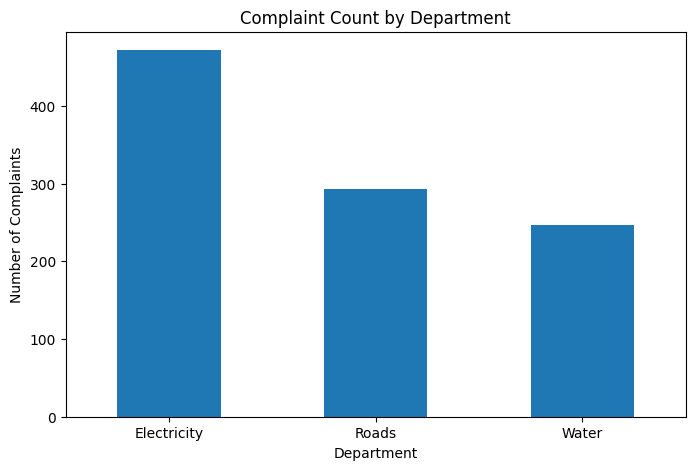

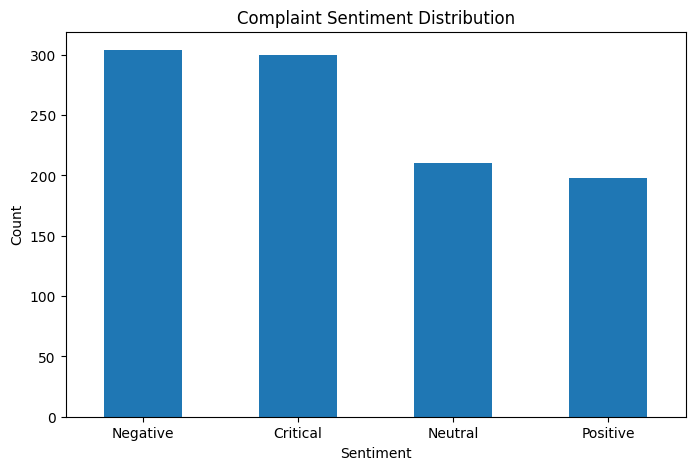

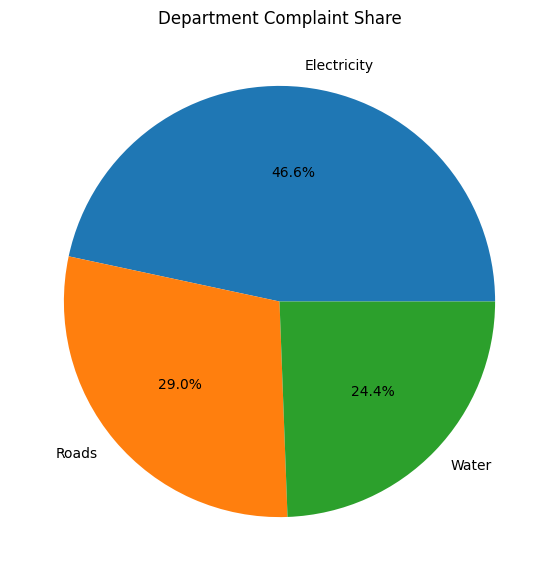

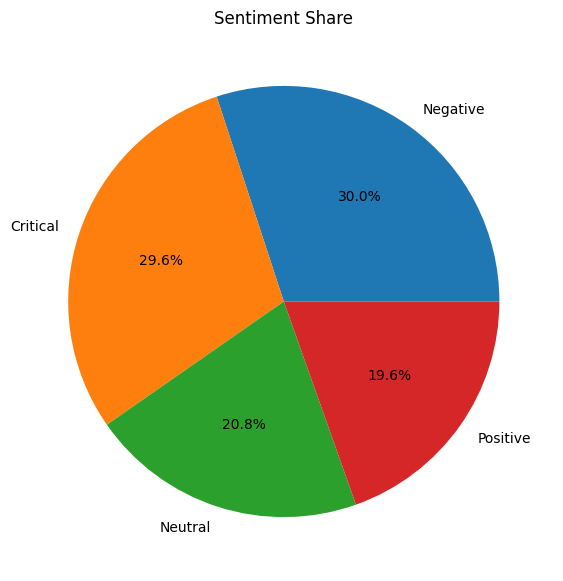

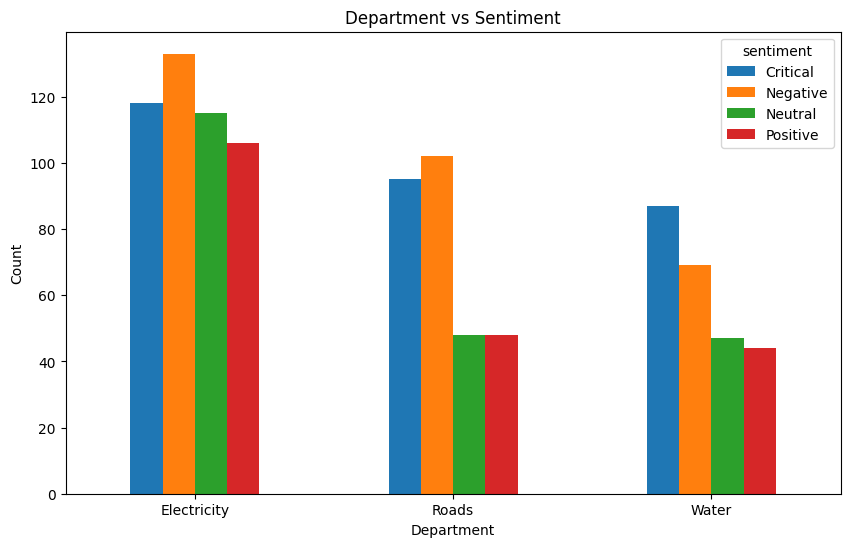

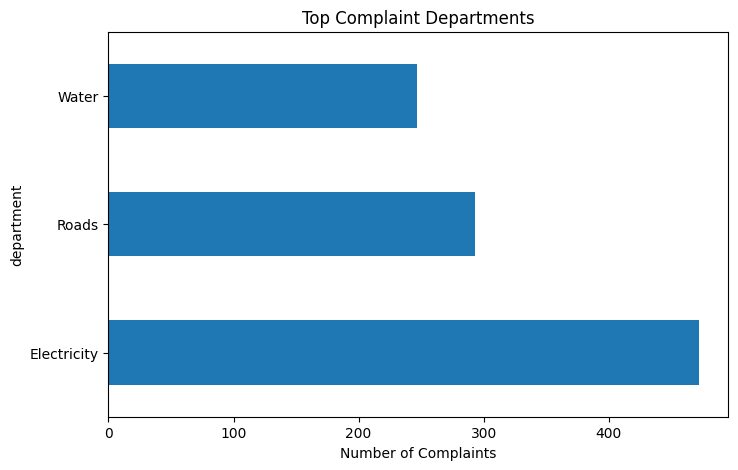

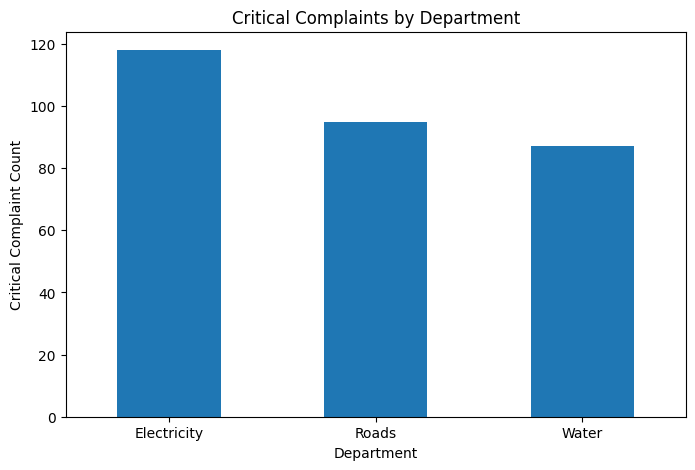

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# LOAD DATASETS
# -----------------------------

roads_data = pd.read_csv(
    "roads.csv"
)

water_data = pd.read_csv(
    "water.csv"
)

electricity_data = pd.read_csv(
    "electricity.csv"
)

# -----------------------------
# MERGE DATASETS
# -----------------------------

df = pd.concat(
    [
        roads_data,
        water_data,
        electricity_data
    ],
    ignore_index=True
)

# -----------------------------
# CLEAN DATA
# -----------------------------

df = (
    df
    .dropna()
    .drop_duplicates()
)

print(
    "Total Complaints:",
    len(df)
)

# ==================================================
# GRAPH 1 - COMPLAINT COUNT BY DEPARTMENT
# ==================================================

department_count = (
    df["department"]
    .value_counts()
)

plt.figure(figsize=(8,5))

department_count.plot(
    kind="bar"
)

plt.title(
    "Complaint Count by Department"
)

plt.xlabel(
    "Department"
)

plt.ylabel(
    "Number of Complaints"
)

plt.xticks(rotation=0)

plt.show()

# ==================================================
# GRAPH 2 - SENTIMENT DISTRIBUTION
# ==================================================

sentiment_count = (
    df["sentiment"]
    .value_counts()
)

plt.figure(figsize=(8,5))

sentiment_count.plot(
    kind="bar"
)

plt.title(
    "Complaint Sentiment Distribution"
)

plt.xlabel(
    "Sentiment"
)

plt.ylabel(
    "Count"
)

plt.xticks(rotation=0)

plt.show()

# ==================================================
# GRAPH 3 - DEPARTMENT PIE CHART
# ==================================================

plt.figure(figsize=(7,7))

plt.pie(
    department_count,
    labels=department_count.index,
    autopct="%1.1f%%"
)

plt.title(
    "Department Complaint Share"
)

plt.show()

# ==================================================
# GRAPH 4 - SENTIMENT PIE CHART
# ==================================================

plt.figure(figsize=(7,7))

plt.pie(
    sentiment_count,
    labels=sentiment_count.index,
    autopct="%1.1f%%"
)

plt.title(
    "Sentiment Share"
)

plt.show()

# ==================================================
# GRAPH 5 - DEPARTMENT VS SENTIMENT
# ==================================================

cross_tab = pd.crosstab(
    df["department"],
    df["sentiment"]
)

cross_tab.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title(
    "Department vs Sentiment"
)

plt.xlabel(
    "Department"
)

plt.ylabel(
    "Count"
)

plt.xticks(rotation=0)

plt.show()

# ==================================================
# GRAPH 6 - TOP COMPLAINT DEPARTMENTS
# ==================================================

plt.figure(figsize=(8,5))

department_count.plot(
    kind="barh"
)

plt.title(
    "Top Complaint Departments"
)

plt.xlabel(
    "Number of Complaints"
)

plt.show()

# ==================================================
# GRAPH 7 - CRITICAL COMPLAINTS BY DEPARTMENT
# ==================================================

critical_df = df[
    df["sentiment"] == "Critical"
]

critical_count = (
    critical_df["department"]
    .value_counts()
)

plt.figure(figsize=(8,5))

critical_count.plot(
    kind="bar"
)

plt.title(
    "Critical Complaints by Department"
)

plt.xlabel(
    "Department"
)

plt.ylabel(
    "Critical Complaint Count"
)

plt.xticks(rotation=0)

plt.show()

<Figure size 800x600 with 0 Axes>

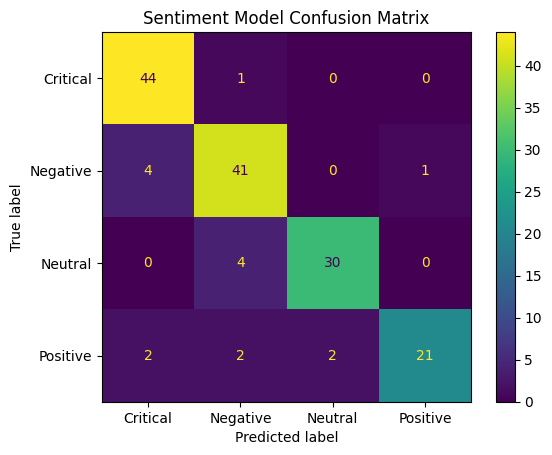

In [2]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.model_selection import (
    train_test_split
)

from sklearn.feature_extraction.text import (
    TfidfVectorizer
)

from sklearn.linear_model import (
    LogisticRegression
)

# -----------------------------
# FEATURES & TARGET
# -----------------------------

X = df[
    "complaint_text"
]

y = df[
    "sentiment"
]

# -----------------------------
# TEXT VECTORIZATION
# -----------------------------

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    stop_words="english",
    max_features=12000,
    sublinear_tf=True
)

X_vectorized = (
    vectorizer.fit_transform(X)
)

# -----------------------------
# TRAIN TEST SPLIT
# -----------------------------

X_train, X_test, y_train, y_test = (
    train_test_split(
        X_vectorized,
        y,
        test_size=0.15,
        random_state=42
    )
)

# -----------------------------
# TRAIN MODEL
# -----------------------------

model = LogisticRegression(
    max_iter=8000,
    C=5,
    class_weight="balanced",
    random_state=42
)

model.fit(
    X_train,
    y_train
)

# -----------------------------
# PREDICTION
# -----------------------------

y_pred = model.predict(
    X_test
)

# -----------------------------
# CONFUSION MATRIX
# -----------------------------

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()

plt.title(
    "Sentiment Model Confusion Matrix"
)

plt.show()